1) **Basic Overview**
   - Shape (rows, columns
   - Data types (int, float, object, datetime
   - Preview (head, tail)

3) **Data Quality Checks**
   - Missing values (count + % per column)
   - Duplicates
   - Invalid values (e.g. negative ages, impossible dates)
   - Consistency (e.g. mixed formats in same column)
     
4) **Univariate Analysis (one variable at a time)**

   Numerical features:
   - Mean, median, std
   - Min / max
   - Distribution (histogram, KDE)
   - Outliers (boxplot)

   Categorical features:
   - Value counts
   - Frequency (%)
   - Rare categories
     
5) **Bivariate Analysis (relationships)**

   Numeric vs Numeric:
   - Scatter plots
   - Correlation (Pearson/Spearman)
     
   Categorical vs Numeric:
   - Grouped stats (mean target per category)
   - Boxplots
     
   Categorical vs Categorical:
   - Crosstab
   - Heatmaps
     

6) **Target Variable Analysis**

   Distribution of target
   - Imbalance (classification)
   - Outliers (regression)
   - Relationship with features

7) **Correlation & Multicollinearity**

   - Correlation matrix
   - Highly correlated features
   - Redundant variables
     
8) **Outliers Analysis**

   - Detect (IQR / Z-score / visual)
   - Understand: error or real signal?
   - Decide: keep / cap / remove

9) **Time-Based Analysis**

    - Trends over time
    - Aggregations (hours)
      
10) **Insights & desicions**



# Libraries

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import math
import seaborn as sns
import matplotlib.pyplot as plt
import math


# Imports

In [8]:
df = pd.read_csv(r'../data/interim_data/telaviv_buses_0704_1304_2024_cleaned_new_features.csv',encoding='utf-8-sig')

# 1. Basic Overview

In [ ]:
### Df shape
df.shape

In [ ]:
### Preview
df.head(5)

In [ ]:
### Data types
df.dtypes


# 2. Data Preperation

In [ ]:
df = df.drop(columns=['route_dir_alt_day_hr', 'line_num_agency_alter_dir', 'SIRI_id', 'gtfs_ride_id', 'gtfs_route_id' ], errors='ignore')
df.dtypes


## Structure the data types

### date

In [ ]:
df['date'] = pd.to_datetime(df['date'])
print(df['date'].dtype)

### day

In [ ]:
# day - categorical with order
day_order = ['Sunday', 'Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday']
df['day'] = pd.Categorical(df['day'], categories=day_order, ordered=True)
print(df['day'].dtype)

### hour

In [ ]:
df = df.rename(columns={'hour_rounded': 'full_hour'})
print(df['full_hour'].dtype)

### line_num

In [ ]:
df['line_num'] = pd.to_numeric(df['line_num'], errors='coerce').astype('Int64')
print(df['line_num'].dtype)

### line_name, alternative, agency_name, origin_city, origin_station, destination_city, destination_station      

In [ ]:
str_cols = ['line_name', 'alternative', 'agency_name', 'origin_city', 
            'origin_station', 'destination_city', 'destination_station', 'route_type']

df[str_cols] = df[str_cols].astype(str)

print(df[str_cols].dtypes)

### Departure & Arrival time planned

In [ ]:
df['departure_time_planned'] = pd.to_datetime(df['departure_time_planned'], format='mixed').dt.time
df['arrival_time_planned'] = pd.to_datetime(df['arrival_time_planned'], format='mixed').dt.time

print(df[['departure_time_planned', 'arrival_time_planned']].dtypes)
print(df[['departure_time_planned', 'arrival_time_planned']].head())

### Route_type

In [ ]:
df['route_type'] = df['route_type'].str.strip()
df = df[df['route_type'] == 'bus']

print(df['route_type'].value_counts())
print(f"Rows after filter: {len(df):,}")

In [ ]:
print(df.groupby('full_hour')['duration_difference_min'].mean().round(2))

In [ ]:
peak_hours = [7, 8, 9, 14, 15, 16, 17]

df['perc_within_pt_route_peak'] = df.apply(
    lambda row: row['perc_within_pt_route'] if row['full_hour'] in peak_hours else 0,
    axis=1
)

print(df[['full_hour', 'perc_within_pt_route', 'perc_within_pt_route_peak']].head(10))
print(f"\nNon-zero values: {(df['perc_within_pt_route_peak'] > 0).sum():,}")

In [ ]:
df['is_peak_hour'] = df['full_hour'].isin(peak_hours).astype(int)
print(df['is_peak_hour'].value_counts())

# 3. Data Quality Checks

## 3.1. Missing values

In [4]:
missing_summary = pd.DataFrame({
    'missing_count': df.isnull().sum(),
    'missing_percent': df.isnull().mean() * 100
})

missing_summary = missing_summary.sort_values(by='missing_percent', ascending=False)

missing_summary

,missing_count,missing_percent
duration_difference_min,19624,21.204132
duration_min_planned,19573,21.149025
speed_kmh_planned,19573,21.149025
Avg_Passengers_Per_Bus,2208,2.385789
Total_Passengers,2208,2.385789
agency_name,185,0.199896
speed_kmh_actual,128,0.138307
duration_min_actual,128,0.138307
curvity,46,0.049704
perc_within_pt_route,46,0.049704


## 3.2. Duplicates

df.duplicated().sum()

## 3.3. Invalid values

The following validation checks were applied to assess data quality:

- `date` — invalid date values after converting from string to datetime
- `hour` — values smaller than 0 or larger than 23
- `number_of_stops` — values smaller than or equal to 0
- `route_length_km` — values smaller than or equal to 0
- `rainfall_mm` — negative values
- `length_in_buffer_m` — negative values
- `duration_min_planned` — values smaller than or equal to 0
- `duration_min_actual` — values smaller than or equal to 0
- `route_length` — values smaller than or equal to 0
- `perc_within_pt_route` — negative values
- `curvity` — values smaller than 1
- `Total_Passengers` — negative values
- `Avg_Passengers_Per_Bus` — negative values

In [10]:
# Copy dataframe if you want to avoid changing the original
df_checked = df.copy()

# Convert date column from string to datetime
# Invalid parsing will become NaT
df_checked['date_converted'] = pd.to_datetime(df_checked['date'], errors='coerce')

# Define invalid value checks
checks = {
    'date_invalid': df_checked['date_converted'].isna(),
    'hour_invalid': (df_checked['hour_rounded'] < 0) | (df_checked['hour_rounded'] > 23),
    'number_of_stops_invalid': df_checked['number_of_stops'] <= 0,
    'route_length_km_invalid': df_checked['route_length_km'] <= 0,
    'rainfall_mm_invalid': df_checked['rainfall_mm'] < 0,
    'length_in_buffer_m_invalid': df_checked['length_in_buffer_m'] < 0,
    'duration_min_planned_invalid': df_checked['duration_min_planned'] <= 0,
    'duration_min_actual_invalid': df_checked['duration_min_actual'] <= 0,
    'route_length_invalid': df_checked['route_length'] <= 0,
    'perc_within_pt_route_invalid': df_checked['perc_within_pt_route'] < 0,
    'curvity_invalid': df_checked['curvity'] < 1,
    'Total_Passengers_invalid': df_checked['Total_Passengers'] < 0,
}

# Build summary table
invalid_summary = pd.DataFrame({
    'Check': list(checks.keys()),
    'Invalid Count': [condition.sum() for condition in checks.values()],
    'Invalid %': [condition.mean() * 100 for condition in checks.values()]
})

invalid_summary['Invalid %'] = invalid_summary['Invalid %'].round(2)

invalid_summary = invalid_summary.sort_values('Invalid %', ascending=False).reset_index(drop=True)

invalid_summary

,Check,Invalid Count,Invalid %
0,date_invalid,0,0.0
1,hour_invalid,0,0.0
2,number_of_stops_invalid,0,0.0
3,route_length_km_invalid,0,0.0
4,rainfall_mm_invalid,0,0.0
5,length_in_buffer_m_invalid,0,0.0
6,duration_min_planned_invalid,0,0.0
7,duration_min_actual_invalid,0,0.0
8,route_length_invalid,0,0.0
9,perc_within_pt_route_invalid,0,0.0


## 3.4. Consistency

In [11]:
consistency_overview = pd.DataFrame({
    'dtype': df.dtypes,
    'unique_values': df.nunique(),
    'sample_values': df.apply(lambda x: x.dropna().astype(str).unique()[:3])
})

consistency_overview

ValueError: 2

## 3.5. Skewness

In [13]:
def highlight(cell_value):
    if cell_value > 1:
        return 'background-color: green;'
    elif cell_value < -1:
        return 'background-color: hotpink;'
    return ''

numerical_cols = ['hour_rounded', 'number_of_stops', 'rainfall_mm', 'Total_Passengers', 
                  'curvity', 'duration_min_planned', 
                  'speed_kmh_planned', 'perc_within_pt_route', 'route_length_km',
                  'duration_difference_min']

pd.DataFrame(df[numerical_cols].skew(), columns=['skewness'])\
    .sort_values(by='skewness', key=lambda x: x.abs(), ascending=False)\
    .style.applymap(highlight)

C:\Users\shaha\AppData\Local\Temp\ipykernel_9000\164407188.py:15: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  .style.applymap(highlight)


,skewness
curvity,15.149521
duration_difference_min,11.687766
rainfall_mm,10.031253
route_length_km,5.616448
duration_min_planned,3.907599
speed_kmh_planned,1.954710
Total_Passengers,1.661843
perc_within_pt_route,0.525129
hour_rounded,0.141588
number_of_stops,-0.056342


# 4. Univariate Analysis

In [14]:
### splitting to numeric and categorial columns
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
categorical_cols = df.select_dtypes(include=['object', 'category']).columns

## 4.1. Numeric columns

### 4.1.1. Summary stats

In [15]:
num_summary = df[numeric_cols].describe().T

num_summary = num_summary[['mean', '50%', 'std', 'min', 'max']]
num_summary = num_summary.rename(columns={'50%': 'median'})

num_summary

,mean,median,std,min,max
hour_rounded,1.282100e+01,1.300000e+01,5.229215,0.000000e+00,2.300000e+01
route_id,1.149116e+04,9.780000e+03,10325.973620,3.900000e+01,3.834300e+04
route_mkt,1.999235e+04,1.504200e+04,15189.293952,1.011200e+04,9.900200e+04
direction,1.496078e+00,1.000000e+00,0.512832,1.000000e+00,3.000000e+00
number_of_stops,3.931763e+01,4.000000e+01,13.075301,2.000000e+00,1.070000e+02
route_length_km,2.429382e+01,1.787900e+01,24.520324,3.190000e+00,3.213640e+02
duration_min_planned,5.496917e+01,5.100000e+01,22.353786,1.900000e+01,3.320000e+02
duration_min_actual,7.148461e+01,6.900000e+01,36.331133,1.000000e+00,1.105000e+03
duration_difference_min,1.669561e+01,1.700000e+01,33.262709,-2.530000e+02,1.076000e+03
speed_kmh_planned,2.469586e+01,1.930000e+01,11.662990,7.500000e+00,7.980000e+01


### 4.1.2. Histograms

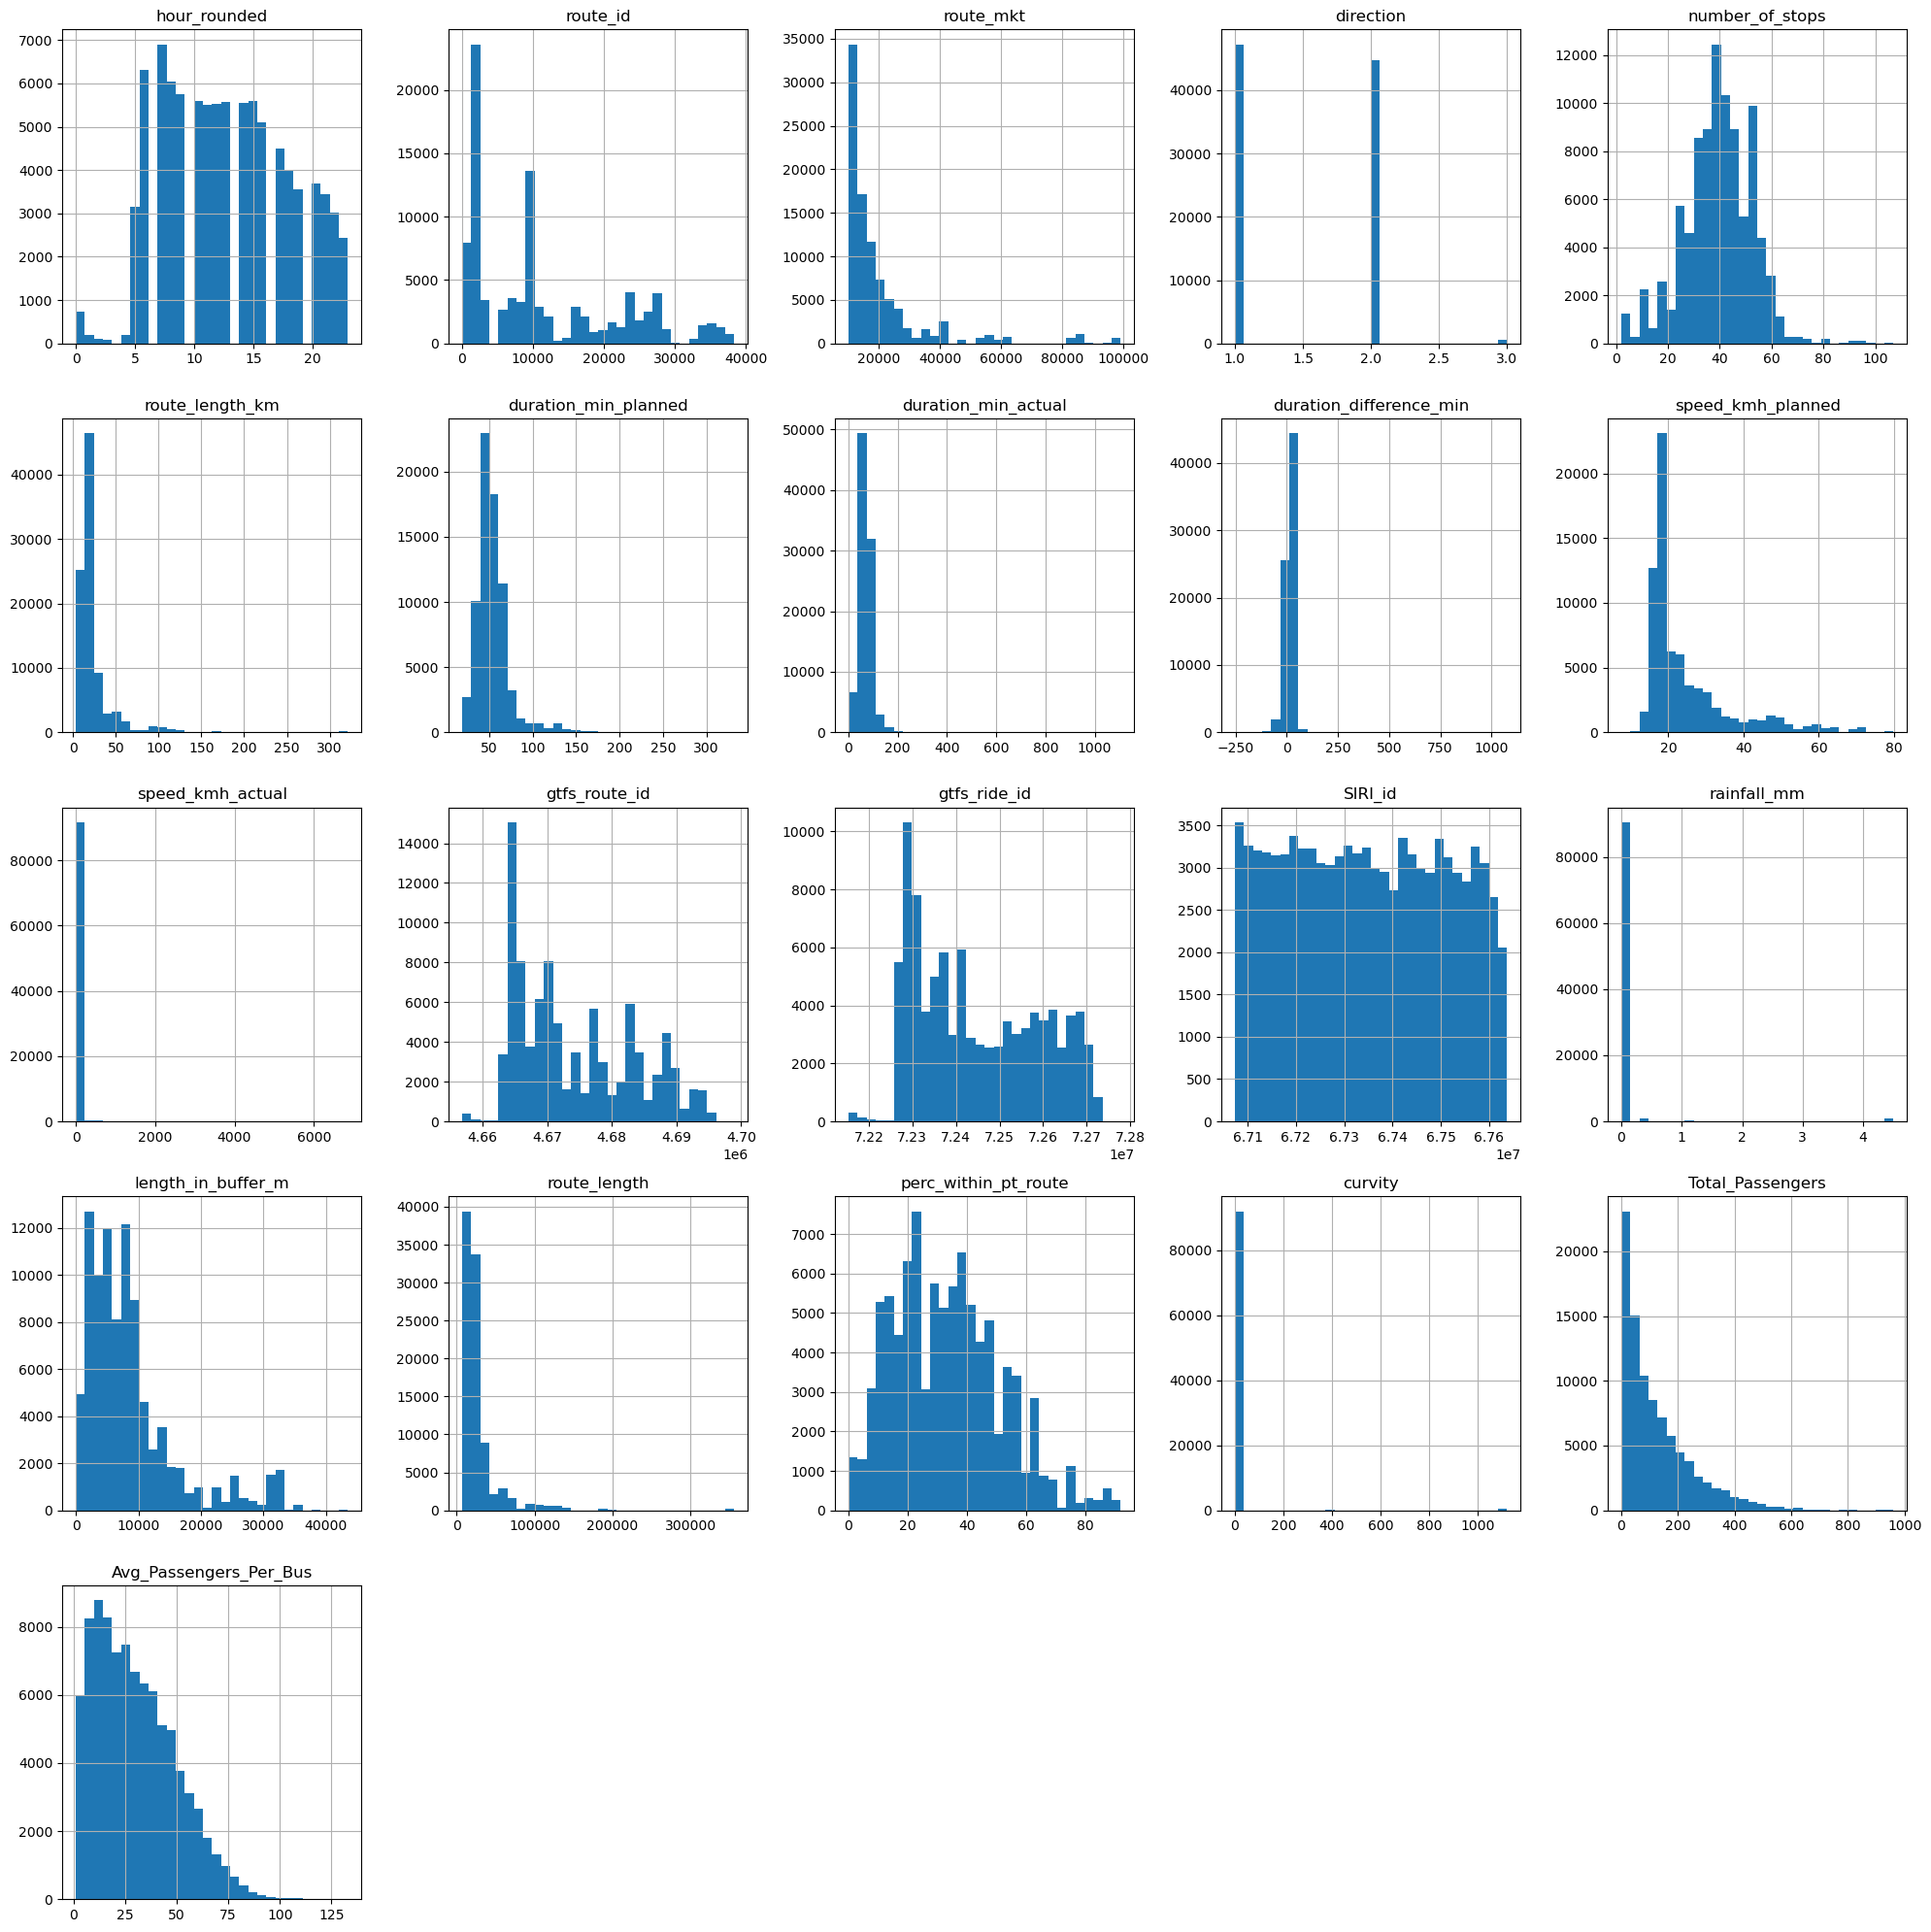

In [16]:


cols = numeric_cols
n_cols = 5
n_rows = math.ceil(len(cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(cols):
    df[col].dropna().hist(ax=axes[i], bins=30)
    axes[i].set_title(col)

# Remove empty plots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

### 4.1.3. Outliers

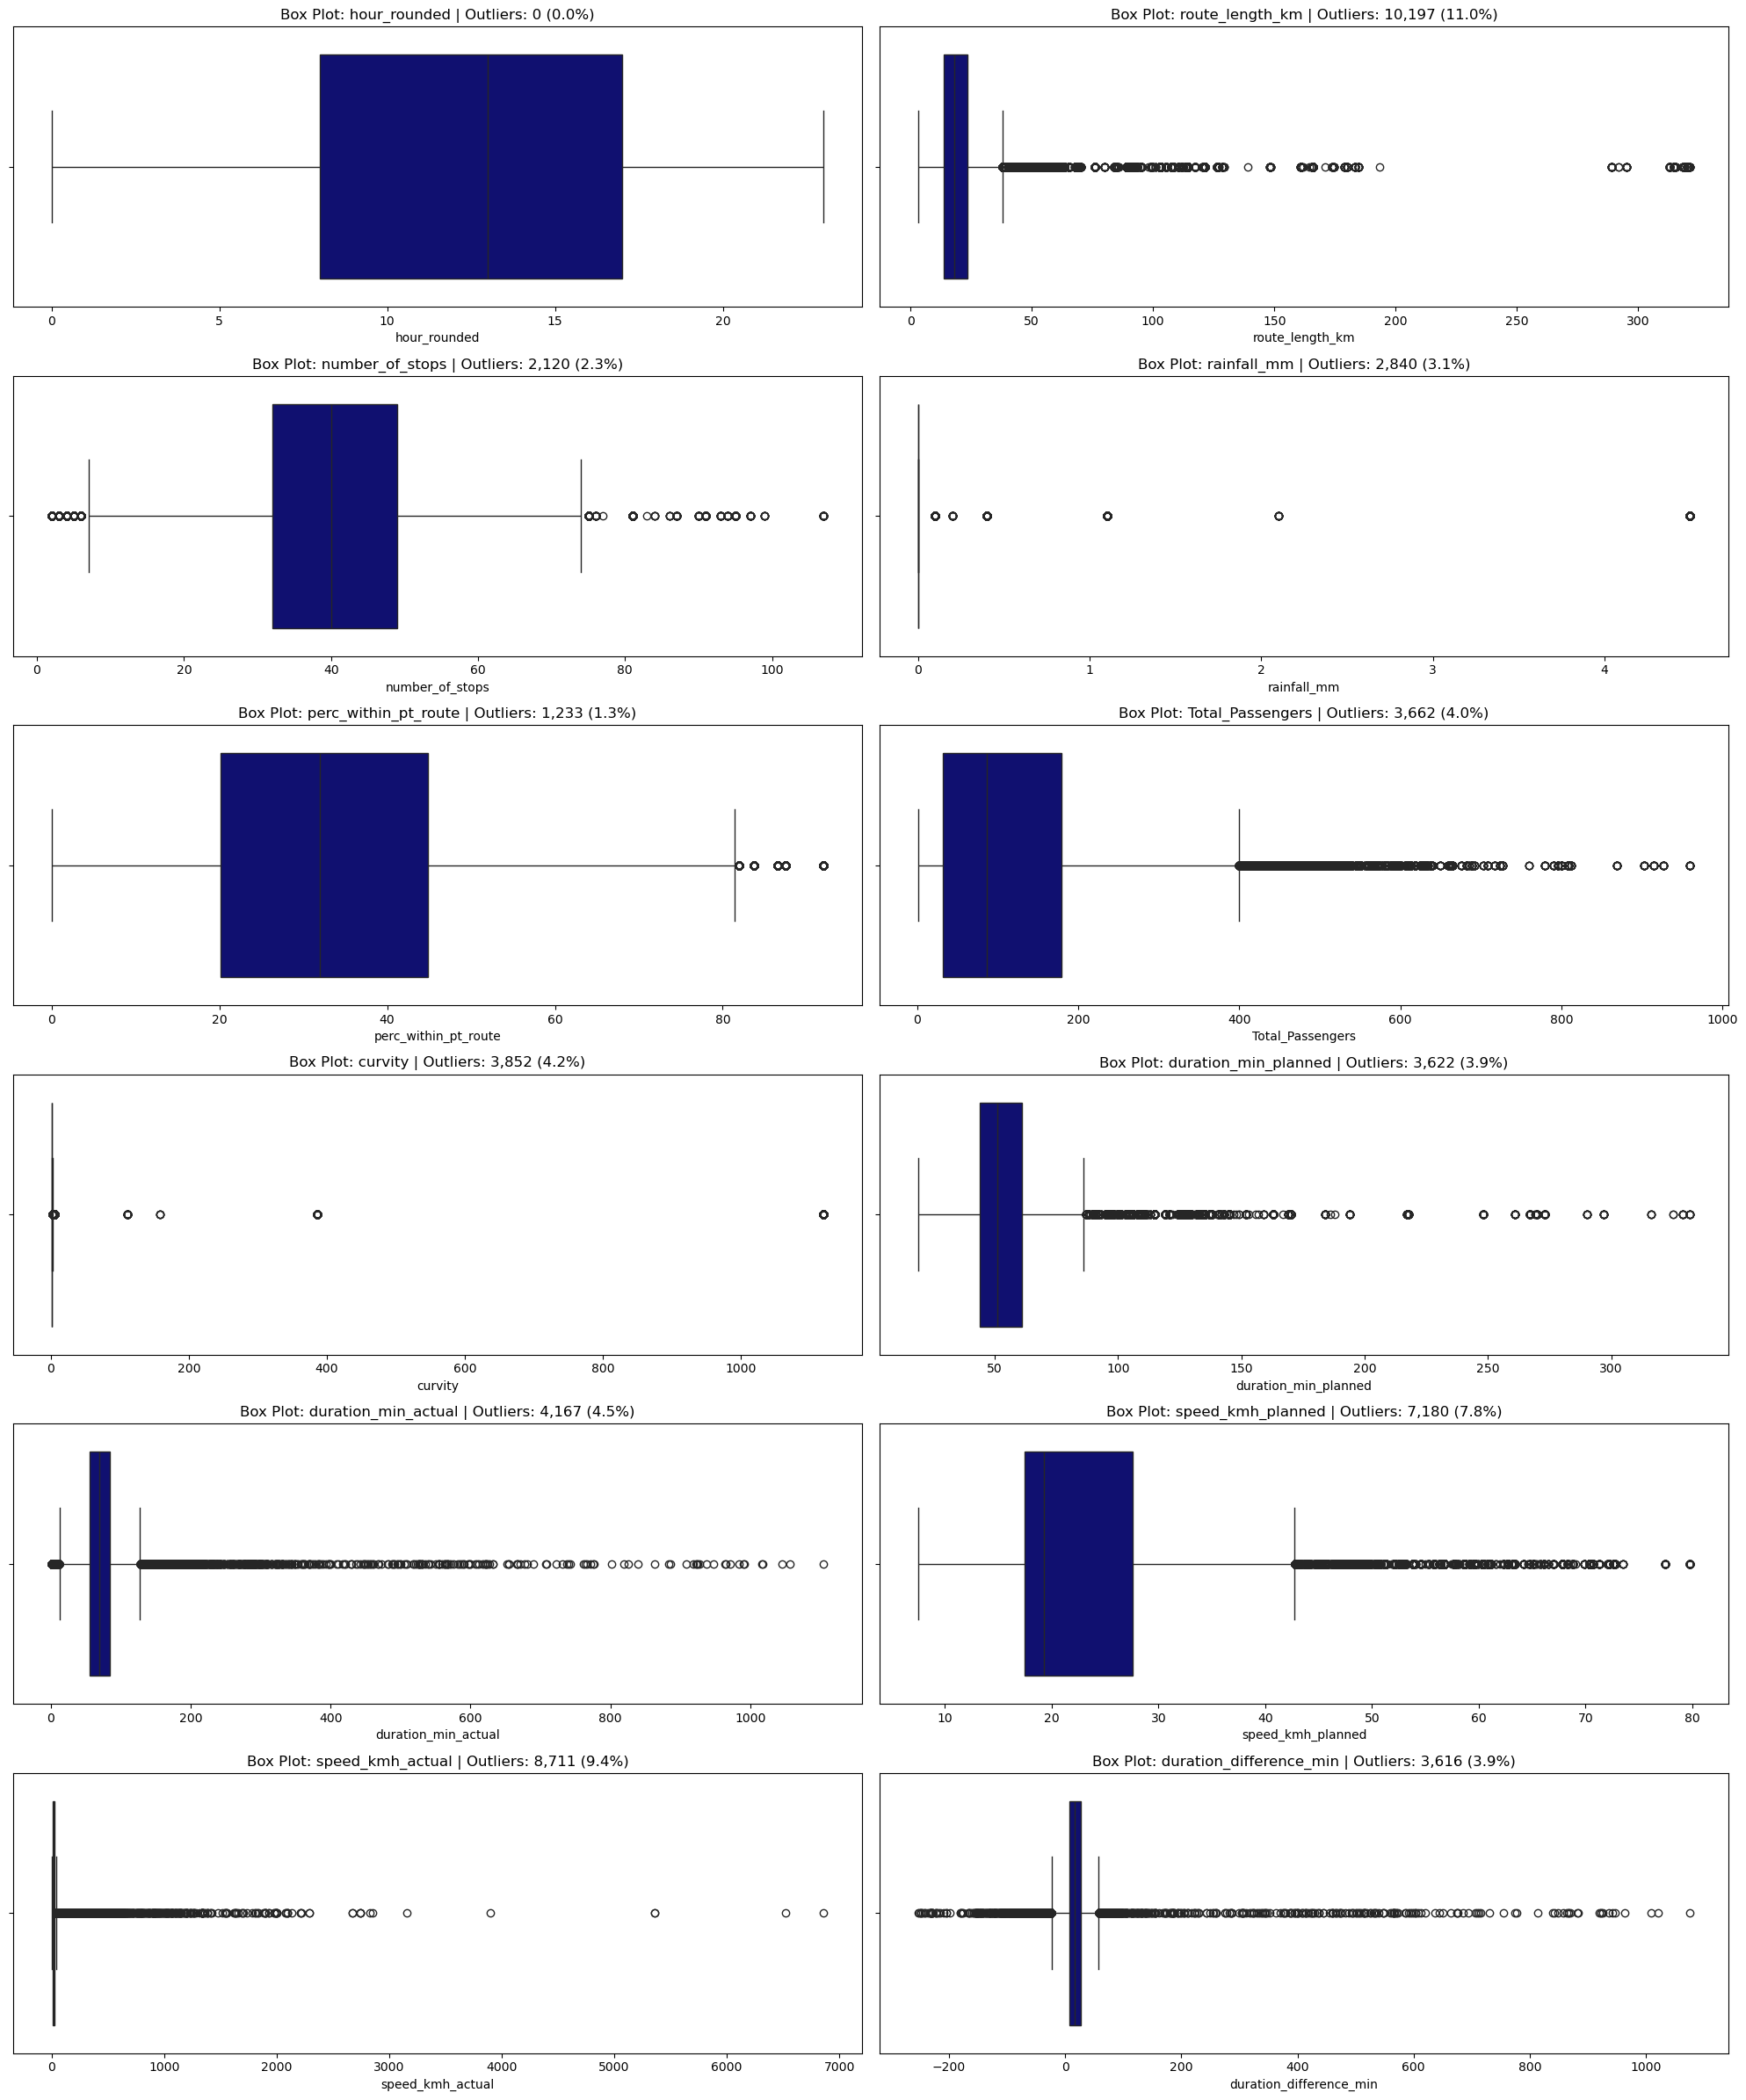

In [17]:
plt.figure(figsize=(20, 24))
cols = ['hour_rounded', 'route_length_km', 'number_of_stops', 'rainfall_mm', 'perc_within_pt_route', 'Total_Passengers', 
        'curvity', 'duration_min_planned', 'duration_min_actual', 'speed_kmh_planned', 'speed_kmh_actual', 'duration_difference_min']

for i, col in enumerate(cols):
    ax = plt.subplot(6, 2, i + 1)
    sns.boxplot(data=df, x=col, ax=ax, color='navy')
    plt.subplots_adjust(hspace=0.5, wspace=0.3)
    
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_outliers = len(df[(df[col] < lower) | (df[col] > upper)])
    pct_outliers = n_outliers / len(df) * 100
    
    plt.title(f'Box Plot: {col} | Outliers: {n_outliers:,} ({pct_outliers:.1f}%)', fontsize=12)
    plt.xlabel(col, fontsize=10)

plt.tight_layout()
plt.show()

#### long routes

In [18]:
df[df['route_length_km'] > 150].head(2)

#### those are Eilat routes - its OK

,date,day,hour_rounded,line_num,line_name,route_id,route_mkt,direction,alternative,agency_name,...,gtfs_ride_id,SIRI_id,rainfall_mm,length_in_buffer_m,route_length,perc_within_pt_route,curvity,route_dir_alt_day_hr,Total_Passengers,Avg_Passengers_Per_Bus
44,2024-04-07,Sunday,0,840,ת.מרכזית תל אביב קומה 7/רציפים-תל אביב יפו<->ת...,19732,10840,1,#,Egged,...,72227919,67073748,0.0,30947.379382,197027.483135,15.71,1.331509,10840_1_#_Sunday_0,3.0,3.0
242,2024-04-07,Sunday,4,390,ת. מרכזית אילת/רציפים-אילת<->ת.מרכזית תל אביב ...,5170,10390,2,#,Egged,...,72175542,67075594,0.0,12694.581432,348977.173773,3.64,1.257403,10390_2_#_Sunday_4,NaN,NaN


## Categorial columns

In [ ]:
categorical_cols = ['day', 'line_name', 'alternative', 'agency_name', 'urban', 'route_type',
                    'origin_city', 'origin_station', 'destination_city', 'destination_station']

n_cols = 3
n_rows = -(-len(categorical_cols) // n_cols)  # עיגול למעלה

fig, axes = plt.subplots(n_rows, n_cols, figsize=(25, n_rows * 6))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    df[col].value_counts().head(10).plot(kind='bar', ax=axes[i])
    axes[i].set_title(col, fontsize=12)
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=45, labelsize=9)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

# 5. Bivariate Analysis (relationships)

## 5.1. Numeric vs Numeric

In [ ]:
# Pearson
corr_pearson = df[numerical_cols].corr(method='pearson')

# Spearman
corr_spearman = df[numerical_cols].corr(method='spearman')

fig, axes = plt.subplots(1, 2, figsize=(28, 10))

sns.heatmap(corr_pearson, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, ax=axes[0])
axes[0].set_title('Correlation Matrix - Pearson', fontsize=14)

sns.heatmap(corr_spearman, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, ax=axes[1])
axes[1].set_title('Correlation Matrix - Spearman', fontsize=14)

plt.tight_layout()
plt.show()

In [ ]:
numerical_cols = ['full_hour', 'number_of_stops', 'Total_Passengers', 
                  'curvity', 'duration_min_planned', 'speed_kmh_planned', 
                  'perc_within_pt_route', 'route_length_km', 'duration_difference_min']

sns.pairplot(df[numerical_cols + ['agency_name']].dropna().sample(2000), 
             hue='agency_name', diag_kind='kde')
plt.suptitle('Pairplot of Numerical Features by agency_name', y=1.02, fontsize=14)
plt.show()

### Is Total_Passengers consumption difference is statistically significant?

In [ ]:
from scipy import stats

# חלק את הדאטה לשתי קבוצות - מעל ומתחת לחציון
median_passengers = df['Total_Passengers'].median()

group_high = df[df['Total_Passengers'] > median_passengers]['duration_difference_min'].dropna()
group_low = df[df['Total_Passengers'] <= median_passengers]['duration_difference_min'].dropna()

# T Test
t_stat, p_value = stats.ttest_ind(group_high, group_low)

print(f"Median Total_Passengers: {median_passengers:.2f}")
print(f"Group High - Mean delay: {group_high.mean():.2f} min")
print(f"Group Low  - Mean delay: {group_low.mean():.2f} min")
print(f"\nT-statistic: {t_stat:.4f}")
print(f"P-value:     {p_value:.6f}")

if p_value < 0.05:
    print("\n✅ Statistically significant (p < 0.05)")
    print("Total_Passengers has a significant effect on duration_difference_min")
else:
    print("\n❌ Not statistically significant (p >= 0.05)")

In [ ]:
plt.figure(figsize=(20, 7))
sns.histplot(group_high, kde=True, color='blue', label=f'High Passengers (>{median_passengers:.0f})', alpha=0.5)
sns.histplot(group_low, kde=True, color='green', label=f'Low Passengers (<={median_passengers:.0f})', alpha=0.5)
plt.title(f'Distribution of Duration Difference by Total Passengers\nT-stat: {t_stat:.4f} | P-value: {p_value:.6f}')
plt.xlabel('Duration Difference (min)')
plt.ylabel('Frequency')
plt.xlim(-100, 100)
plt.legend()
plt.grid(True)
plt.show()

## 5.2. Categorical vs Numeric

## 5.3. Categorical vs Categorical

# 6. Target Analysis

In [ ]:
df['duration_difference_min'] = df['duration_min_actual'] - df['duration_min_planned']

print(df['duration_difference_min'].describe())

In [ ]:
plt.figure(figsize=(20, 8))
sns.histplot(df['duration_difference_min'])
plt.title('Distribution of Duration Difference (min)', fontsize=14)
plt.xlabel('Duration Difference (min)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.show()

In [ ]:
plt.figure(figsize=(10, 6))
df['duration_difference_min'].plot(kind='box')
plt.title('Duration Difference (min) - Box Plot')
plt.ylabel('Minutes')
plt.show()

print(df['duration_difference_min'].describe())

In [ ]:
Q1 = df['duration_difference_min'].quantile(0.25)
Q3 = df['duration_difference_min'].quantile(0.75)
IQR = Q3 - Q1

lower_fence = Q1 - 1.5 * IQR
upper_fence = Q3 + 1.5 * IQR

within_box = df[(df['duration_difference_min'] >= lower_fence) & 
                (df['duration_difference_min'] <= upper_fence)]
outliers = df[(df['duration_difference_min'] < lower_fence) | 
              (df['duration_difference_min'] > upper_fence)]

print(f"Q1:                  {Q1}")
print(f"Q3:                  {Q3}")
print(f"IQR:                 {IQR}")
print(f"Lower fence:         {lower_fence}")
print(f"Upper fence:         {upper_fence}")
print(f"Values within box:   {len(within_box):,} ({len(within_box)/len(df)*100:.1f}%)")
print(f"Outliers:            {len(outliers):,} ({len(outliers)/len(df)*100:.1f}%)")
print(f"Outliers below:      {len(df[df['duration_difference_min'] < lower_fence]):,}")
print(f"Outliers above:      {len(df[df['duration_difference_min'] > upper_fence]):,}")

## Target anf numeric values corr

In [ ]:
numerical_cols = ['full_hour', 'route_length_km', 'number_of_stops', 'rainfall_mm', 
                  'perc_within_pt_route', 'Total_Passengers', 'curvity', 
                  'duration_min_planned', 'speed_kmh_planned']

n_cols = 3
n_rows = -(-len(numerical_cols) // n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(25, n_rows * 6))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    # הסר NaN ביחד
    temp = df[[col, 'duration_difference_min']].dropna()
    x = temp[col]
    y = temp['duration_difference_min']
    
    axes[i].scatter(x, y, alpha=0.1, color='steelblue', s=5)
    
    # קו מגמה
    z = np.polyfit(x, y, 1)
    p = np.poly1d(z)
    axes[i].plot(sorted(x), p(sorted(x)), color='red', linewidth=2)
    
    corr = x.corr(y, method='spearman')
    axes[i].set_title(f'{col} vs duration_difference_min\nSpearman: {corr:.3f}', fontsize=12)
    axes[i].set_xlabel(col, fontsize=10)
    axes[i].set_ylabel('duration_difference_min', fontsize=10)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [ ]:
numerical_cols = ['full_hour', 'route_length_km', 'number_of_stops', 'rainfall_mm', 
                  'perc_within_pt_route', 'Total_Passengers', 'curvity', 'perc_within_pt_route_peak', 'is_peak_hour',
                  'duration_min_planned', 'speed_kmh_planned']

# חשב קורלציה עם המטרה
corr_with_target = df[numerical_cols].corrwith(df['duration_difference_min'], method='spearman').sort_values()

# צבע לפי חיובי/שלילי
colors = ['red' if x < 0 else 'steelblue' for x in corr_with_target]

plt.figure(figsize=(12, 6))
bars = plt.barh(corr_with_target.index, corr_with_target.values, color=colors)

# data labels
for bar, val in zip(bars, corr_with_target.values):
    plt.text(val + 0.005 if val >= 0 else val - 0.005,
             bar.get_y() + bar.get_height() / 2,
             f'{val:.3f}', va='center', ha='left' if val >= 0 else 'right', fontsize=10)

plt.axvline(x=0, color='black', linewidth=0.8)
plt.title('Spearman Correlation with duration_difference_min', fontsize=14)
plt.xlabel('Correlation', fontsize=12)
plt.tight_layout()
plt.show()

## Target and categorical values corr

In [ ]:
categorical_cols = ['day', 'alternative', 'agency_name', 'origin_city', 'destination_city', 'urban']

n_cols = 2
n_rows = -(-len(categorical_cols) // n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(25, n_rows * 8))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    order = df.groupby(col)['duration_difference_min'].median().sort_values().index
    sns.boxplot(data=df, x=col, y='duration_difference_min',
                order=order, ax=axes[i], color='steelblue')
    axes[i].set_title(f'{col} vs duration_difference_min', fontsize=12)
    axes[i].set_xlabel(col, fontsize=10)
    axes[i].set_ylabel('duration_difference_min', fontsize=10)
    axes[i].tick_params(axis='x', rotation=45)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [ ]:
plt.figure(figsize=(30, 8))

order = df.groupby('origin_city')['duration_difference_min'].median().sort_values().index
sns.boxplot(data=df, x='origin_city', y='duration_difference_min',
            order=order, color='steelblue')

plt.title('origin_city vs duration_difference_min', fontsize=14)
plt.xlabel('origin_city', fontsize=12)
plt.ylabel('duration_difference_min', fontsize=12)
plt.xticks(rotation=90, fontsize=12)
plt.tight_layout()
plt.show()

# 7. Split data

Before performing any missing values or outliers manipulatations - first we need to split the data to:
- Train (60%)
- Validation(10%)
- Test (30%)

In [ ]:
X = df.drop(columns='duration_difference_min')
y = df['duration_difference_min']

# First split: train (60%) and temp (40%)
train_df, temp_df = train_test_split(df, test_size=0.4, random_state=42)

# Second split: validation (10%) and test (30%)
val_df, test_df = train_test_split(temp_df, test_size=0.75, random_state=42)

## Save 
train_df.to_csv(r'../data/model_datasets/train_df.csv',index=False,encoding='utf-8-sig')
test_df.to_csv(r'../data/model_datasets/test_df.csv',index=False,encoding='utf-8-sig')
val_df.to_csv(r'../data/model_datasets/val_df.csv',index=False,encoding='utf-8-sig')